Productos cargados: 243 registros


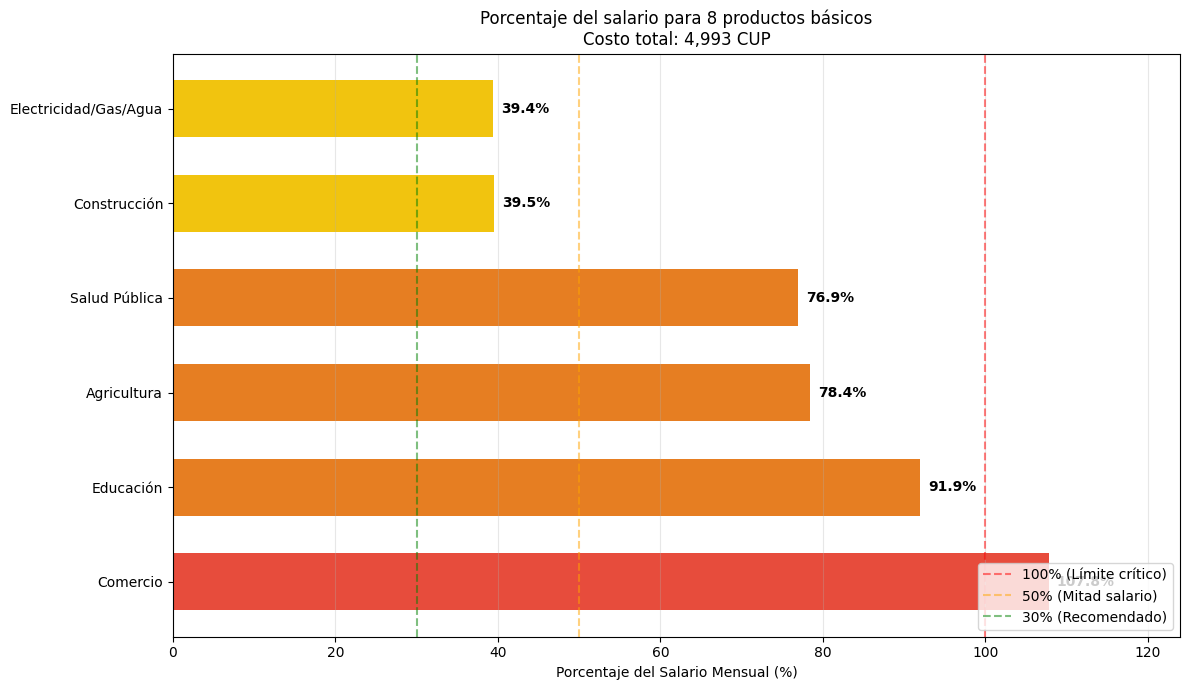

In [2]:


import json
import sys
from matplotlib import pyplot as plt

sys.path.append('../Biblioteca_Funciones')
# Configuración simple
plt.rcParams['figure.figsize'] = (12, 7)

# Celda 2: Cargar datos
# Cargar productos
with open('../Data/Procesados/productos_planos.json', 'r', encoding='utf-8') as f:
    productos = json.load(f)

print(f"Productos cargados: {len(productos)} registros")

# Celda 3: Importar y ejecutar análisis
from A4 import analizar_asequibilidad

# Ejecutar análisis
resultados, costo_canasta, resumen = analizar_asequibilidad(
    ruta_salarios='../Data/Crudos/salarios_cuba/salarios.json',
    productos=productos
)

# Celda 4: Preparar datos para el gráfico
sectores = list(resultados.keys())
porcentajes = [resultados[s]['porcentaje'] for s in sectores]

# Ordenar de mayor a menor
datos_ordenados = sorted(zip(sectores, porcentajes), key=lambda x: x[1], reverse=True)
sectores_ordenados = [d[0] for d in datos_ordenados]
porcentajes_ordenados = [d[1] for d in datos_ordenados]

# Simplificar nombres
nombres_cortos = []
for sector in sectores_ordenados:
    if sector == "Suministro de electricidad , gas y agua":
        nombres_cortos.append("Electricidad/Gas/Agua")
    elif sector == "Salud pública y asistencia social":
        nombres_cortos.append("Salud Pública")
    elif sector == "Agricultura , ganadería y silvicultura":
        nombres_cortos.append("Agricultura")
    elif sector == "Comercio y reparación de efectos personales":
        nombres_cortos.append("Comercio")
    else:
        nombres_cortos.append(sector)

# Celda 5: Crear UN SOLO GRÁFICO
fig, ax = plt.subplots()

# Colores según porcentaje
colores = []
for p in porcentajes_ordenados:
    if p > 100:
        colores.append('#e74c3c')  # Rojo
    elif p > 50:
        colores.append('#e67e22')  # Naranja
    elif p > 30:
        colores.append('#f1c40f')  # Amarillo
    else:
        colores.append('#2ecc71')  # Verde

# Barras horizontales
bars = ax.barh(nombres_cortos, porcentajes_ordenados, color=colores, height=0.6)

# Líneas de referencia
ax.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='100% (Límite crítico)')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='50% (Mitad salario)')
ax.axvline(x=30, color='green', linestyle='--', alpha=0.5, label='30% (Recomendado)')

# Añadir valores a las barras
for bar, valor in zip(bars, porcentajes_ordenados):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{valor:.1f}%',
            va='center',
            fontsize=10,
            fontweight='bold')

# Configurar gráfico
ax.set_xlabel('Porcentaje del Salario Mensual (%)')
ax.set_title(f'Porcentaje del salario para 8 productos básicos\nCosto total: {costo_canasta:,.0f} CUP')

# Leyenda
ax.legend(loc='lower right')

# Cuadrícula y límites
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(porcentajes_ordenados) * 1.15)

# Mostrar gráfico
plt.tight_layout()
plt.show()
